# Vaccine Response Analysis
**Dataset:** BNT162b2 vaccination time course (GEO GSE171964)


## Background
This dataset profiles PBMCs collected at baseline and after BNT162b2 vaccination, capturing short-term immune dynamics.

> **Single-arm longitudinal study** — all participants received the vaccine. Analyses focus on within-participant changes (Day 0 vs Day 7) rather than treatment vs control comparisons. Participant-level aggregation avoids treating cells as independent observations, and multiple testing is controlled using FDR.


## 1. Setup


In [1]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
# Note: We do NOT suppress UserWarning — the package issues useful
# recommendations (e.g. use_bootstrap=True for small samples)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["axes.grid"] = False
import seaborn as sns
sns.set_style("white")
sns.set_context("notebook")
import scanpy as sc
import sctrial as st
pd.options.mode.chained_assignment = None
# Configuration
SEED = 42
MIN_PAIRED = 4
MIN_GENES_FOR_SCORE = 5
FDR_ALPHA = 0.25  # Exploratory threshold; use 0.05 for confirmatory analyses


def _fmt_fdr(v):
    """Format FDR/p-value: scientific notation for very small values."""
    return f"{v:.2e}" if v < 0.001 else f"{v:.3f}"


## 2. Data Loading and Processing


In [2]:
# Dataset loader and helpers (from sctrial)
# Also available at top-level: st.load_vaccine_gse171964, st.verify_paired_participants, st.ensure_fdr
from sctrial.datasets import load_vaccine_gse171964, verify_paired_participants, ensure_fdr


### 2.1 Load processed AnnData


In [3]:
adata = load_vaccine_gse171964(
    seed=SEED,
    allow_download=True,
)
print(adata)
print("Obs columns:")
print(sorted(adata.obs.columns.tolist()))

AnnData object with n_obs × n_vars = 78456 × 15640
    obs: 'pt_id', 'day', 'clustnm', 'sample_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'annotation_source'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'is_hb', 'is_ribo', 'is_histone', 'is_artifact'
    uns: 'annotation_source', 'artifact_classes_dropped', 'artifact_genes_removed', 'cells_per_participant_visit', 'log1p', 'n_adt_features', 'processing_params'
    obsm: 'protein'
    layers: 'counts', 'log1p_norm'
Obs columns:
['annotation_source', 'clustnm', 'day', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'log1p_total_counts_mt', 'n_genes', 'n_genes_by_counts', 'pct_counts_in_top_100_genes'

### 2.2 Quick exploratory summaries


Days: [0 7]
Participants: 6
Cell types: 18
Participants per day:
day
0    6
7    6
Name: pt_id, dtype: int64


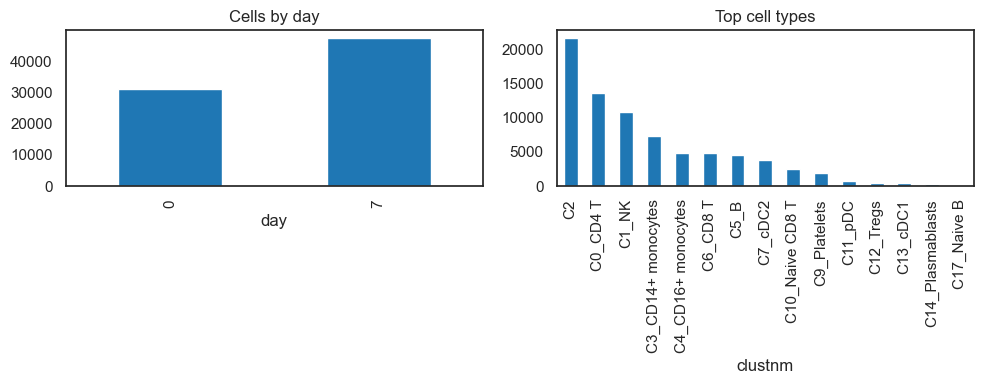

In [4]:
print("Days:", adata.obs["day"].unique())
print("Participants:", adata.obs["pt_id"].nunique())
print("Cell types:", adata.obs["clustnm"].nunique())
# Participants per day (before pairing restriction for analysis)
pt_per_day = adata.obs.groupby("day")["pt_id"].nunique().sort_index()
print("Participants per day:")
print(pt_per_day)
# Cell counts
eday_counts = adata.obs["day"].value_counts().sort_index()
ct_counts = adata.obs["clustnm"].value_counts().head(15)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
eday_counts.plot(kind="bar", ax=axes[0], title="Cells by day")
ct_counts.plot(kind="bar", ax=axes[1], title="Top cell types")
plt.tight_layout(); plt.show()


## 3. Trial Design and Timepoint Strategy


In [5]:
# Standardize metadata
adata.obs["visit"] = adata.obs["day"].astype(str)
adata.obs["participant_id"] = adata.obs["pt_id"].astype(str)
adata.obs["cell_type"] = adata.obs["clustnm"].astype(str)
visit_col = "visit"
visits = [v for v in ["0", "7"] if v in adata.obs[visit_col].unique()]
# Participant-level pairing
participant_summary = (
    adata.obs.groupby("participant_id")[visit_col].apply(set).reset_index()
)
participant_summary["has_day0"] = participant_summary[visit_col].apply(lambda x: "0" in x)
participant_summary["has_day7"] = participant_summary[visit_col].apply(lambda x: "7" in x)
participant_summary["is_paired"] = participant_summary["has_day0"] & participant_summary["has_day7"]
paired_ids = set(participant_summary.loc[participant_summary["is_paired"], "participant_id"])
n_paired = len(paired_ids)
print(f"Paired participants (0 vs 7): {n_paired}")
# Analysis subset: paired participants only
adata_analysis = adata[adata.obs["participant_id"].isin(paired_ids)].copy()
print(f"Analysis subset cells: {adata_analysis.n_obs}")
# Covariates (if available)
candidate_covariates = ["age", "sex", "batch", "site"]
covariates = [c for c in candidate_covariates if c in adata.obs.columns]
print("Covariates available (not modeled here):", covariates)

# Design object for a SINGLE-ARM longitudinal study.
# All participants received vaccine — there is no control arm.
# arm_col=None tells sctrial this is a single-arm design.
# Analyses use within_arm_comparison() for paired pre→post inference,
# NOT between-arm DiD.
design = st.TrialDesign(
    participant_col="participant_id",
    visit_col=visit_col,
    arm_col=None,           # Single-arm study — no arm column
    celltype_col="cell_type",
)

# Run diagnostics
print("\n--- Trial Diagnostics ---")
diag = st.diagnose_trial_data(adata_analysis, design)
display(diag)

design

Paired participants (0 vs 7): 6
Analysis subset cells: 78456
Covariates available (not modeled here): []

--- Trial Diagnostics ---


{'n_cells': 78456,
 'n_genes': 15640,
 'n_participants': 6,
 'n_visits': 2,
 'visits': ['0', '7'],
 'paired_participants': {('0', '7'): 6},
 'cells_per_participant_visit_mean': np.float64(6538.0),
 'cells_per_participant_visit_median': np.float64(5345.0),
 'cells_per_participant_visit_min': np.int64(3463),
 'n_celltypes': 18,
 'celltype_distribution': {'C2': 21632,
  'C0_CD4 T': 13633,
  'C1_NK': 10816,
  'C3_CD14+ monocytes': 7308,
  'C4_CD16+ monocytes': 4872,
  'C6_CD8 T': 4861,
  'C5_B': 4597,
  'C7_cDC2': 3876,
  'C10_Naive CD8 T': 2464,
  'C9_Platelets': 1871,
  'C11_pDC': 741,
  'C12_Tregs': 465,
  'C13_cDC1': 388,
  'C14_Plasmablasts': 294,
  'C17_Naive B': 222,
  'C16_NK T': 204,
  'C15_HPCs': 182,
  'C8_CD14+BDCA1+PD-L1+ cells': 30},
 'warnings': [],
 'recommendations': ['Sample size is small; use bootstrap inference (use_bootstrap=True)']}

TrialDesign(participant_col='participant_id', visit_col='visit', arm_col=None, arm_treated='Treated', arm_control='Control', celltype_col='cell_type', crossover_col=None, baseline_visit=None, followup_visit=None)

### 3.1 Exploratory plots of cell types per visit


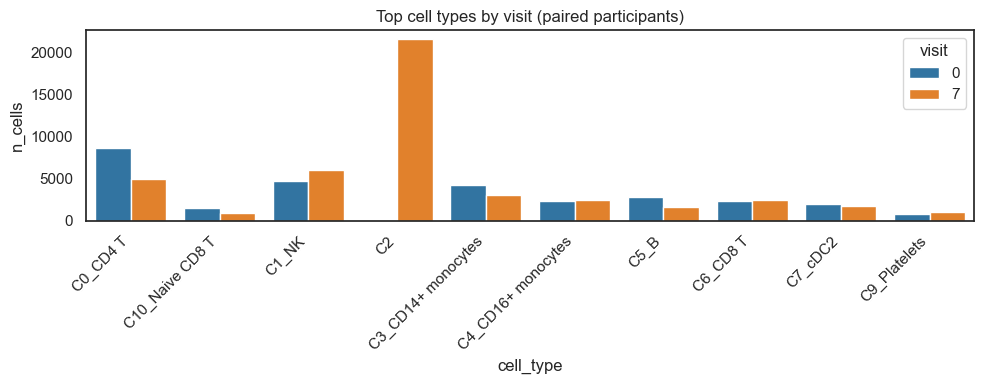

In [6]:
ct_visit = (
    adata_analysis.obs
    .groupby([design.celltype_col, design.visit_col], observed=True)
    .size()
    .reset_index(name="n_cells")
)
top_ct = adata_analysis.obs[design.celltype_col].value_counts().head(10).index
ct_visit_top = ct_visit[ct_visit[design.celltype_col].isin(top_ct)].copy()
plt.figure(figsize=(10, 4))
sns.barplot(data=ct_visit_top, x=design.celltype_col, y="n_cells", hue=design.visit_col)
plt.title("Top cell types by visit (paired participants)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout(); plt.show()


## 4. UMAPs of All Cell Types

Here, we explore global structure across all cell types to understand broad immune landscape changes.


/Users/vasanthakup/Documents/Work/umcAmsterdam/sctrial/sctrial_venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


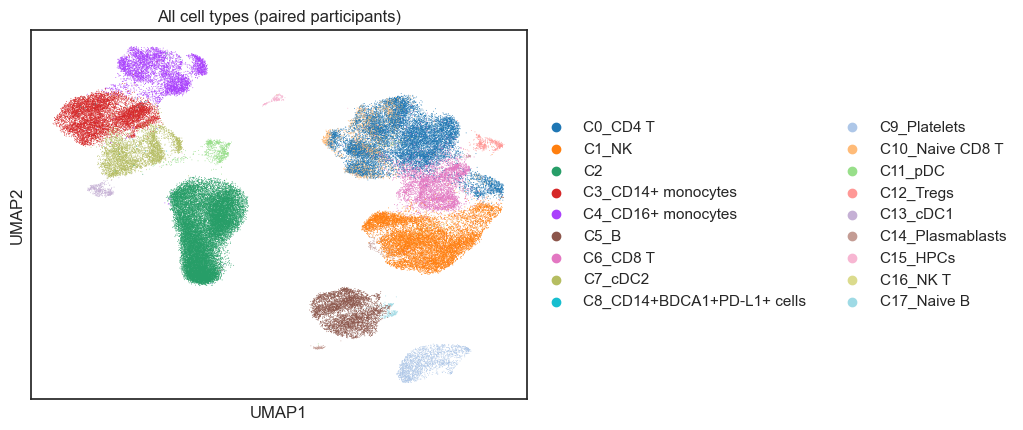

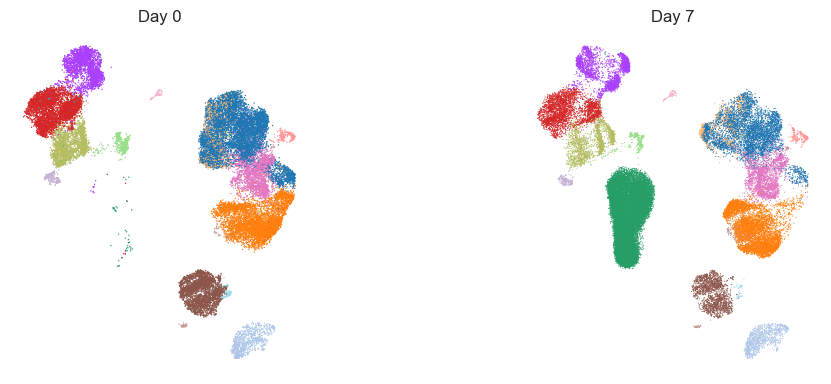

In [7]:
# Compute UMAP on log1p norm if missing
adata_umap = adata_analysis.copy()
adata_umap.X = adata_umap.layers["log1p_norm"].copy()
if "X_umap" not in adata_umap.obsm:
    sc.pp.pca(adata_umap)
    sc.pp.neighbors(adata_umap)
    sc.tl.umap(adata_umap)
sc.pl.umap(
    adata_umap,
    color=design.celltype_col,
    legend_loc="right margin",
    title="All cell types (paired participants)",
)
# Stratified UMAPs by visit
fig, axes = plt.subplots(1, len(visits), figsize=(12, 4))
if len(visits) == 1:
    axes = [axes]
for i, vis in enumerate(visits):
    sub = adata_umap[adata_umap.obs[design.visit_col] == vis].copy()
    ax = axes[i]
    if sub.n_obs > 0:
        sc.pl.umap(sub, color=design.celltype_col, ax=ax, show=False, legend_loc=None, frameon=False)
        ax.set_title(f"Day {vis}")
        ax.set_aspect('equal')
    else:
        ax.set_axis_off()
plt.tight_layout(); plt.show()


## 5. Module Scoring and Gene Panel

Here, we define biologically motivated signatures and a focused gene panel for downstream within‑arm testing.


In [8]:
available = set(adata_analysis.var_names)

# Canonical 19-signature dictionary (matches manuscript figures _shared.py)
gene_signatures = {
    "Cytotoxic T Cell Activity": [
        "GZMB", "GZMA", "GZMH", "GZMK", "GZMM", "PRF1", "GNLY", "NKG7",
        "KLRK1", "KLRD1", "KLRG1", "FASLG", "IFNG", "CST7", "CCL5",
        "CX3CR1", "FGFBP2",
    ],
    "T Cell Exhaustion": [
        "TOX", "TOX2", "PDCD1", "HAVCR2", "LAG3", "TIGIT", "ENTPD1",
        "CXCL13", "LAYN", "CD38", "PRDM1", "BATF", "NR4A2", "NR4A3",
        "CD160", "CD244",
    ],
    "Checkpoint Receptors": [
        "PDCD1", "CTLA4", "LAG3", "HAVCR2", "TIGIT", "BTLA", "CD160",
        "CD244", "CD96",
    ],
    "Type I Interferon": [
        "ISG15", "IFI27", "IFI44", "IFI44L", "IFI35", "MX1", "OAS1",
        "OASL", "IFIT2", "IFIT3", "IFITM3", "RSAD2", "LY6E", "USP18",
        "IRF7", "STAT2", "ISG20", "BST2", "HERC6", "EPSTI1", "SAMD9L",
        "PARP9", "RTP4", "LGALS3BP", "CMPK2",
    ],
    "Type II Interferon": [
        "STAT1", "IRF1", "GBP1", "GBP2", "GBP4", "GBP5", "CXCL9",
        "CXCL10", "CXCL11", "IDO1", "SOCS1", "SOCS3", "JAK2", "UBE2L6",
        "WARS", "IL18BP", "VCAM1", "SERPING1", "FGL2", "IFI30",
    ],
    "Memory T Cell": [
        "IL7R", "TCF7", "LEF1", "CCR7", "SELL", "CD27", "CD28", "ID3",
        "REL", "FOXP1", "BACH2", "MYB", "FOXO1", "KLF2", "S1PR1",
    ],
    "T Cell Activation": [
        "CD69", "CD44", "IL2RA", "ICOS", "TNFRSF4", "TNFRSF9", "CD40LG",
        "EGR1", "EGR2", "EGR3", "NR4A1", "MYC", "IL2RB", "IRF4",
        "TNFRSF18",
    ],
    "Inflammatory Response": [
        "IL1B", "IL6", "TNF", "CXCL8", "CCL2", "CCL3", "CCL4", "NFKB1",
        "NLRP3", "CASP1", "CXCL1", "CXCL2", "CXCL3", "CCL20", "PTGS2",
        "IL1A", "TNFAIP3", "NFKBIA", "IL18", "S100A8", "S100A9",
    ],
    "Antigen Presentation": [
        "HLA-A", "HLA-B", "HLA-C", "B2M", "TAP1", "TAP2", "TAPBP",
        "NLRC5", "PSMB8", "PSMB9", "PSMB10", "CIITA", "CD74", "HLA-DRA",
        "HLA-DRB1", "HLA-DPA1", "HLA-DPB1", "HLA-DQA1", "HLA-DMA",
        "HLA-DMB", "CTSS",
    ],
    "Cell Proliferation": [
        "MKI67", "TOP2A", "PCNA", "CDK1", "CCNB1", "CCNA2", "MCM2",
        "MCM7", "TYMS", "BIRC5", "UBE2C", "CENPF", "CENPE", "CCNB2",
        "RRM2", "HMGB2", "TPX2", "NUSAP1", "CKS2", "AURKA", "CKS1B",
        "STMN1",
    ],
    "Regulatory T Cell": [
        "FOXP3", "IKZF2", "IKZF4", "IL2RA", "CTLA4", "TNFRSF18",
        "TNFRSF4", "TNFRSF9", "TIGIT", "ENTPD1", "LRRC32", "RTKN2",
        "CCR8", "LAYN", "IL1R2",
    ],
    "NK Cell Activity": [
        "FCGR3A", "NCR1", "NCR3", "NCR2", "KLRF1", "KLRC1", "KLRC2",
        "KLRD1", "KLRB1", "IL2RB", "TBX21", "GZMM", "SH2D1B", "GNLY",
        "NKG7",
    ],
    "Apoptosis": [
        "BAX", "BAK1", "BID", "BCL2L11", "BBC3", "PMAIP1", "CASP3",
        "CASP7", "CASP8", "CASP9", "FAS", "TNFRSF10B", "DIABLO", "APAF1",
        "CDKN1A", "GADD45A", "GADD45B", "DDIT3", "FDXR", "BTG2",
    ],
    "Oxidative Stress Response": [
        "NFE2L2", "HMOX1", "NQO1", "GCLC", "GCLM", "GSR", "SOD1", "SOD2",
        "CAT", "GPX1", "TXN", "TXNRD1", "PRDX1", "PRDX2", "SRXN1",
        "G6PD", "GPX4", "GLRX", "SLC7A11",
    ],
    "Humoral Plasma Cell": [
        "MS4A1", "CD79A", "CD79B", "CD19", "CD37", "BANK1", "TCL1A",
        "FCRL5", "POU2AF1", "MZB1", "JCHAIN", "XBP1", "PRDM1", "DERL3",
        "SDC1", "TNFRSF17", "SEC11C", "HERPUD1", "FKBP11", "SLAMF7",
        "IGHM", "IGHG1", "IGKC", "IGLC2", "FDCSP",
    ],
    "Monocyte Macrophage": [
        "CD14", "CD68", "LYZ", "CSF1R", "AIF1", "TYROBP", "FCER1G",
        "CTSS", "FCGR3A", "ITGAM", "MNDA", "CD163", "MRC1", "MSR1",
        "MARCO", "APOE", "C1QA", "C1QB", "C1QC", "TREM2", "SELENOP",
        "LGALS3", "FCN1", "VCAN", "S100A9",
    ],
    "Tissue-Resident Memory": [
        "ITGAE", "ITGA1", "CXCR6", "ZNF683", "CD101", "RGS1", "RGS2",
        "DUSP6", "RBPJ", "CD69", "ID2", "PRDM1", "NR4A1", "DUSP1",
        "EGR1",
    ],
    "T Follicular Helper": [
        "CXCL13", "CXCR5", "PDCD1", "ICOS", "BCL6", "TOX", "TOX2",
        "IL21", "BTLA", "CD200", "MAF", "ASCL2", "SH2D1A", "CD40LG",
        "TNFRSF4", "BATF",
    ],
    "Hypoxia": [
        "VEGFA", "SLC2A1", "SLC2A3", "HK1", "HK2", "PGK1", "LDHA",
        "ALDOA", "ENO1", "PDK1", "BNIP3L", "NDRG1", "ADM", "ANGPTL4",
        "DDIT4", "PPP1R15A", "ERO1A", "P4HA1", "CA12", "IGFBP3", "PLIN2",
    ],
}

print("Gene set coverage (19 canonical signatures):")
filtered = {}
for name, genes in gene_signatures.items():
    present = [g for g in genes if g in available]
    pct = len(present) / len(genes) * 100 if genes else 0
    status = "OK" if len(present) >= MIN_GENES_FOR_SCORE else "SKIP"
    print(f"  {name}: {len(present)}/{len(genes)} genes ({pct:.0f}%) [{status}]")
    if len(present) >= MIN_GENES_FOR_SCORE:
        filtered[name] = present
if filtered:
    adata_analysis = st.score_gene_sets(
        adata_analysis, filtered, layer="log1p_norm", method="zmean", prefix="sig_"
    )
    print(f"\nScored {len(filtered)} gene sets using zmean.")
else:
    print(f"\nNo gene sets matched (min_genes={MIN_GENES_FOR_SCORE}); skipping module scoring.")
features = [c for c in adata_analysis.obs.columns if c.startswith("sig_")]
print("Signature score features:", features)
# Panel genes for individual gene analysis
panel_genes_all = [
    # B cell
    "CD79A", "CD79B", "MS4A1", "MZB1", "XBP1",
    # IFN
    "ISG15", "IFI6", "IFIT1", "MX1",
    # Inflammatory
    "S100A8", "S100A9", "LYZ", "VCAN",
    # T cell activation
    "CD69", "CD38", "IL2RA",
    # Cytotoxic
    "GZMB", "PRF1", "NKG7",
]
panel_genes = [g for g in panel_genes_all if g in available]
missing_panel = [g for g in panel_genes_all if g not in available]
print("\nPanel genes (available):", panel_genes)
if missing_panel:
    print("Panel genes missing:", missing_panel)


Gene set coverage (19 canonical signatures):
  Cytotoxic T Cell Activity: 17/17 genes (100%) [OK]
  T Cell Exhaustion: 15/16 genes (94%) [OK]
  Checkpoint Receptors: 9/9 genes (100%) [OK]
  Type I Interferon: 25/25 genes (100%) [OK]
  Type II Interferon: 20/20 genes (100%) [OK]
  Memory T Cell: 15/15 genes (100%) [OK]
  T Cell Activation: 15/15 genes (100%) [OK]
  Inflammatory Response: 21/21 genes (100%) [OK]
  Antigen Presentation: 21/21 genes (100%) [OK]
  Cell Proliferation: 22/22 genes (100%) [OK]
  Regulatory T Cell: 15/15 genes (100%) [OK]
  NK Cell Activity: 14/15 genes (93%) [OK]
  Apoptosis: 20/20 genes (100%) [OK]
  Oxidative Stress Response: 18/19 genes (95%) [OK]
  Humoral Plasma Cell: 24/25 genes (96%) [OK]
  Monocyte Macrophage: 25/25 genes (100%) [OK]
  Tissue-Resident Memory: 15/15 genes (100%) [OK]
  T Follicular Helper: 14/16 genes (88%) [OK]
  Hypoxia: 21/21 genes (100%) [OK]

Scored 19 gene sets using zmean.
Signature score features: ['sig_Cytotoxic T Cell Activity

In [9]:
# ============================================================================
# PAIRING VERIFICATION (package helper)
# ============================================================================
print("=" * 60)
print("PAIRING VERIFICATION (based on valid signature scores)")
print("=" * 60)
paired_info = verify_paired_participants(
    adata_analysis.obs,
    visit_col=visit_col,
    visits=visits,
    features=features,
    participant_col="participant_id",
)
VALID_PAIRED_IDS = paired_info["paired_ids"]
N_VALID_PAIRED = paired_info["n_paired"]
print("")
print(f"Participants with valid Day0+Day7 scores for ALL features: {N_VALID_PAIRED}")
print(f"Total participants: {paired_info['n_total']}")
if paired_info["dropped_ids"]:
    print(f"Dropped (missing visit or NaN features): {len(paired_info['dropped_ids'])}")
else:
    print("All paired participants have valid scores ✓")
print("")
print(f"Using {N_VALID_PAIRED} validated paired participants for analyses.")


PAIRING VERIFICATION (based on valid signature scores)

Participants with valid Day0+Day7 scores for ALL features: 6
Total participants: 6
All paired participants have valid scores ✓

Using 6 validated paired participants for analyses.


## 6. Within-Arm Comparisons (Participant-Level)

Here, we run paired within‑participant analyses to determine which module scores change from Day 0 to Day 7.

> **Bootstrap inference:** With only 6 paired participants, cluster-robust asymptotic p-values are anti-conservative. We use `use_bootstrap=True` (wild cluster bootstrap-t; Cameron et al. 2008) to obtain reliable p-values, standard errors, and confidence intervals. The bootstrap p-value replaces the analytical p-value as the primary inferential quantity.

WITHIN-ARM COMPARISONS: MODULE SCORES (Day 0 vs Day 7)


/var/folders/xl/pr40r62n3wx54s8_6cgjzg2c0000gt/T/ipykernel_15815/292175458.py:7: UserWarning: Only 6 clusters (participants) available. Cluster-robust standard errors are unreliable with fewer than 10 clusters.
  res_within = st.within_arm_comparison(
/var/folders/xl/pr40r62n3wx54s8_6cgjzg2c0000gt/T/ipykernel_15815/292175458.py:7: UserWarning: Only 6 clusters (participants) available. Cluster-robust standard errors are unreliable with fewer than 10 clusters.
  res_within = st.within_arm_comparison(
/var/folders/xl/pr40r62n3wx54s8_6cgjzg2c0000gt/T/ipykernel_15815/292175458.py:7: UserWarning: Only 6 clusters (participants) available. Cluster-robust standard errors are unreliable with fewer than 10 clusters.
  res_within = st.within_arm_comparison(
/var/folders/xl/pr40r62n3wx54s8_6cgjzg2c0000gt/T/ipykernel_15815/292175458.py:7: UserWarning: Only 6 clusters (participants) available. Cluster-robust standard errors are unreliable with fewer than 10 clusters.
  res_within = st.within_arm_comp

,feature,beta_time,se_time,p_time,p_time_boot,se_time_boot,ci_lo_boot,ci_hi_boot,FDR_time,n_units
0,sig_Cytotoxic T Cell Activity,1.2195,0.4262,0.013,0.013,0.5480,0.2600,1.9252,0.0823,6
1,sig_T Cell Exhaustion,0.5606,0.5827,0.227,0.227,0.4094,-0.4149,1.5361,0.4059,6
2,sig_Checkpoint Receptors,0.6635,0.7285,0.187,0.187,0.4998,-0.5087,1.8357,0.3948,6
3,sig_Type I Interferon,0.9397,0.3714,0.013,0.013,0.4371,0.1148,1.4745,0.0823,6
4,sig_Type II Interferon,0.2371,0.4410,0.509,0.509,0.2888,-0.3412,0.8153,0.7878,6
5,sig_Memory T Cell,-0.8563,0.7818,0.116,0.116,0.6005,-1.7983,0.0858,0.3064,6
6,sig_T Cell Activation,-0.8541,0.6796,0.129,0.129,0.5568,-1.8040,0.0958,0.3064,6
7,sig_Inflammatory Response,-0.1863,0.5518,0.539,0.539,0.3465,-0.7956,0.4230,0.7878,6
8,sig_Antigen Presentation,0.9368,0.7925,0.113,0.113,0.6218,-0.0692,1.9429,0.3064,6
9,sig_Cell Proliferation,1.1648,0.4436,0.013,0.013,0.5345,0.5592,1.7704,0.0823,6



Module score changes (FDR < 0.25):
  sig_Cytotoxic T Cell Activity: increased (beta=1.220, FDR=0.082)
  sig_Type I Interferon: increased (beta=0.940, FDR=0.082)
  sig_Cell Proliferation: increased (beta=1.165, FDR=0.082)
  sig_NK Cell Activity: increased (beta=1.098, FDR=0.119)

Boxplots show participant-level distributions by day; points indicate individual participants.


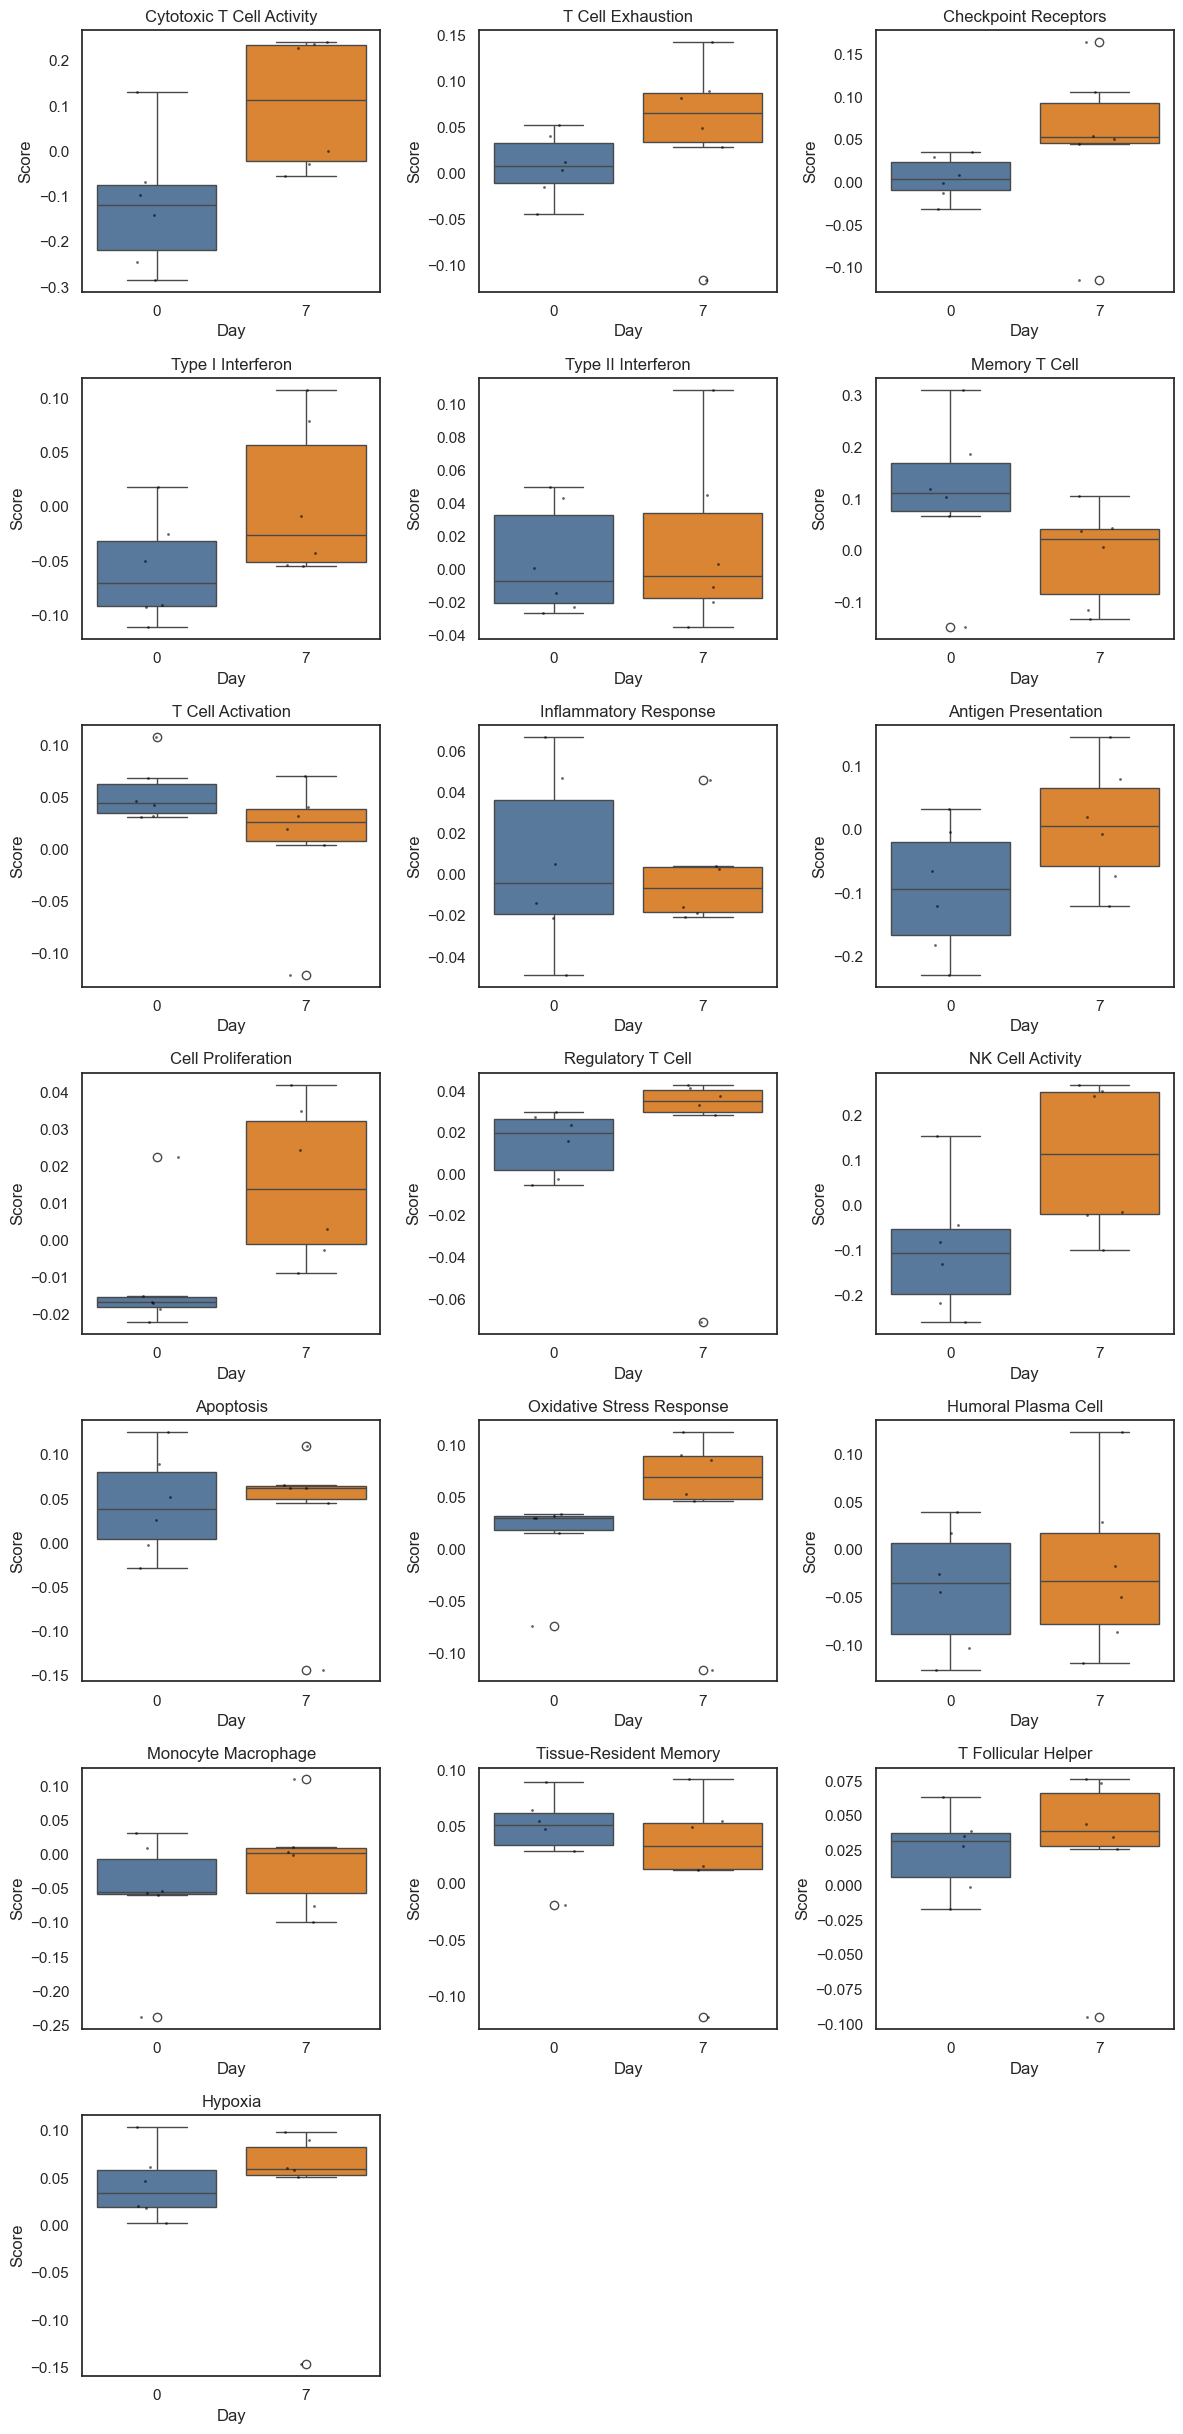

In [10]:
print("=" * 60)
print("WITHIN-ARM COMPARISONS: MODULE SCORES (Day 0 vs Day 7)")
print("=" * 60)
res_within = pd.DataFrame()
if features and len(visits) == 2:
    ad_sub = adata_analysis[adata_analysis.obs["participant_id"].isin(VALID_PAIRED_IDS)].copy()
    res_within = st.within_arm_comparison(
        ad_sub,
        arm="All",
        features=features,
        design=design,
        visits=tuple(visits),
        aggregate="participant_visit",
        standardize=True,
        use_bootstrap=True,   # Recommended for small n (6 participants)
        n_boot=999,
        seed=SEED,
    )
    if res_within is not None and not res_within.empty:
        # Use package helper for FDR correction
        res_within = ensure_fdr(res_within, p_col="p_time", fdr_col="FDR_time")
        display_cols = [
            "feature", "beta_time", "se_time", "p_time",
            "p_time_boot", "se_time_boot", "ci_lo_boot", "ci_hi_boot",
            "FDR_time", "n_units",
        ]
        display_cols = [c for c in display_cols if c in res_within.columns]
        display(res_within[display_cols].round(4))
        sig = res_within[(res_within["FDR_time"].notna()) & (res_within["FDR_time"] < FDR_ALPHA)]
        if not sig.empty:
            print("")
            print(f"Module score changes (FDR < {FDR_ALPHA}):")
            for _, row in sig.iterrows():
                direction = "increased" if row["beta_time"] > 0 else "decreased"
                print(f"  {row['feature']}: {direction} (beta={row['beta_time']:.3f}, FDR={_fmt_fdr(row['FDR_time'])})")
        else:
            print("")
            print(f"No module scores reached FDR < {FDR_ALPHA}.")
    else:
        print("No within-arm results for module scores.")
else:
    print("Insufficient features or visits for within-arm comparisons.")
print("")
print("Boxplots show participant-level distributions by day; points indicate individual participants.")
# Plot participant-level module scores by day
if features and len(visits) == 2:
    df_plot = (
        adata_analysis.obs
        .groupby(["participant_id", "visit"], observed=True)[features]
        .mean()
        .reset_index()
    )
    n_feats = len(features)
    n_cols = min(3, n_feats)
    n_rows = (n_feats + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3.5*n_rows))
    axes = np.array(axes).reshape(-1)
    for i, feat in enumerate(features):
        ax = axes[i]
        sns.boxplot(
            data=df_plot,
            x="visit",
            y=feat,
            hue="visit",
            ax=ax,
            order=visits,
            palette={"0": "#4C78A8", "7": "#F58518"},
            dodge=False,
            linewidth=1,
        )
        sns.stripplot(
            data=df_plot,
            x="visit",
            y=feat,
            ax=ax,
            order=visits,
            color="black",
            size=2,
            alpha=0.6,
            jitter=0.15,
        )
        ax.set_title(feat.replace("sig_", ""))
        ax.set_xlabel("Day")
        ax.set_ylabel("Score")
        if ax.legend_:
            ax.legend_.remove()
    for j in range(i+1, len(axes)):
        axes[j].axis("off")
    plt.tight_layout()
    plt.show()

### Module-Score Pseudobulk by Cell Type (Within-Arm)

Here, we aggregate module scores to participant×visit×cell_type (pseudobulk) and test paired Day 0→Day 7 changes within the vaccinated arm for each cell type.


,pool,module,mean_delta,p_time,n_units,FDR_time
109,C14_Plasmablasts,sig_T Cell Exhaustion,0.142461,0.0625,5,0.265625
264,C5_B,sig_Type I Interferon,0.053654,0.0625,5,0.193182
266,C6_CD8 T,sig_Antigen Presentation,0.052512,0.0625,5,0.265625
268,C6_CD8 T,sig_Cell Proliferation,0.022254,0.0625,5,0.354167
269,C6_CD8 T,sig_Checkpoint Receptors,0.053534,0.0625,5,0.265625
270,C6_CD8 T,sig_Cytotoxic T Cell Activity,0.160467,0.0625,5,0.354167
271,C6_CD8 T,sig_Humoral Plasma Cell,0.023123,0.0625,5,0.531250
188,C1_NK,sig_Type I Interferon,0.081275,0.0625,5,0.193182
272,C6_CD8 T,sig_Hypoxia,0.053507,0.0625,5,0.177083
276,C6_CD8 T,sig_NK Cell Activity,0.100696,0.0625,5,0.265625


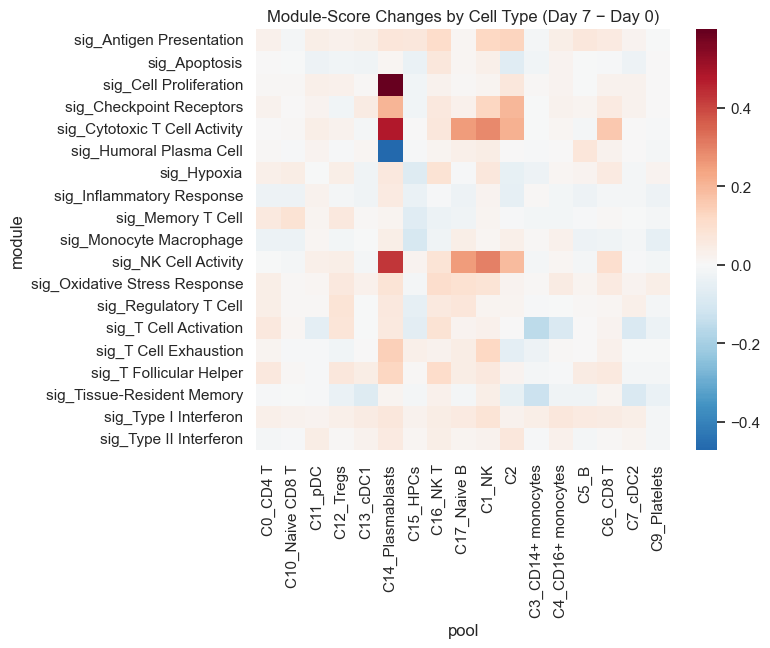

In [11]:
if features and len(visits) == 2:
    pb_mod = st.module_score_pseudobulk(
        adata_analysis,
        module_cols=features,
        design=design,
        visits=tuple(visits),
        pool_col="cell_type",
        min_cells_per_group=5,
    )
    res_mod_ct = st.module_score_within_arm_by_pool(
        pb_mod,
        design=design,
        visits=tuple(visits),
        min_paired=3,
        fdr_within="module",
    )
    if not res_mod_ct.empty:
        display(res_mod_ct.sort_values("p_time").head(20))
        pivot = res_mod_ct.pivot(index="module", columns="pool", values="mean_delta")
        plt.figure(figsize=(8, max(4, 0.35*len(pivot))))
        sns.heatmap(pivot, cmap="RdBu_r", center=0)
        plt.title("Module-Score Changes by Cell Type (Day 7 − Day 0)")
        plt.tight_layout()
        plt.show()
    else:
        print("No valid pseudobulk module-score results for cell types.")
else:
    print("Skipping pseudobulk module-score analysis: insufficient features or visits.")


## 7. Gene Expression Within-Arm (Panel Genes)

Here, we test targeted panel genes for within‑arm changes using participant‑level aggregation.


WITHIN-ARM COMPARISONS: PANEL GENES (Day 0 vs Day 7)


/var/folders/xl/pr40r62n3wx54s8_6cgjzg2c0000gt/T/ipykernel_15815/1183823430.py:7: UserWarning: Only 6 clusters (participants) available. Cluster-robust standard errors are unreliable with fewer than 10 clusters.
  res_genes = st.within_arm_comparison(
/var/folders/xl/pr40r62n3wx54s8_6cgjzg2c0000gt/T/ipykernel_15815/1183823430.py:7: UserWarning: Only 6 clusters (participants) available. Cluster-robust standard errors are unreliable with fewer than 10 clusters.
  res_genes = st.within_arm_comparison(
/var/folders/xl/pr40r62n3wx54s8_6cgjzg2c0000gt/T/ipykernel_15815/1183823430.py:7: UserWarning: Only 6 clusters (participants) available. Cluster-robust standard errors are unreliable with fewer than 10 clusters.
  res_genes = st.within_arm_comparison(
/var/folders/xl/pr40r62n3wx54s8_6cgjzg2c0000gt/T/ipykernel_15815/1183823430.py:7: UserWarning: Only 6 clusters (participants) available. Cluster-robust standard errors are unreliable with fewer than 10 clusters.
  res_genes = st.within_arm_comp

,feature,beta_time,se_time,p_time,p_time_boot,se_time_boot,ci_lo_boot,ci_hi_boot,FDR_time,n_units
0,CD79A,-0.2662,0.4199,0.369,0.369,0.2709,-1.3392,0.4154,0.6374,6
1,CD79B,0.0604,0.1399,0.502,0.502,0.0865,-0.1830,0.2915,0.7483,6
2,MS4A1,-0.4681,0.2025,0.071,0.071,0.2268,-0.9361,0.0000,0.2009,6
3,MZB1,0.2957,0.6915,0.817,0.817,0.4347,-0.4681,1.0595,0.9702,6
4,XBP1,0.7067,0.5776,0.102,0.102,0.4355,-0.1745,1.5879,0.2153,6
5,ISG15,1.2355,0.4944,0.025,0.025,0.5835,0.2209,1.9431,0.1188,6
6,IFI6,0.6147,0.5505,0.001,0.001,0.4237,0.0785,1.1398,0.0190,6
7,IFIT1,0.5220,0.3470,0.069,0.069,0.2912,-0.0314,1.0440,0.2009,6
8,MX1,0.3145,0.1806,0.074,0.074,0.1696,-0.0274,0.6564,0.2009,6
9,S100A8,0.1135,1.1115,0.942,0.942,0.6833,-1.3362,1.4943,1.0000,6



Panel genes with significant changes (FDR < 0.25):
  MS4A1: decreased (beta=-0.468, FDR=0.201)
  XBP1: increased (beta=0.707, FDR=0.215)
  ISG15: increased (beta=1.236, FDR=0.119)
  IFI6: increased (beta=0.615, FDR=0.019)
  IFIT1: increased (beta=0.522, FDR=0.201)
  MX1: increased (beta=0.314, FDR=0.201)
  CD38: increased (beta=0.911, FDR=0.219)
  GZMB: increased (beta=1.014, FDR=0.215)
  PRF1: increased (beta=0.924, FDR=0.119)
  NKG7: increased (beta=1.191, FDR=0.119)

Boxplots show participant-level log1p norm by day; points indicate individual participants.


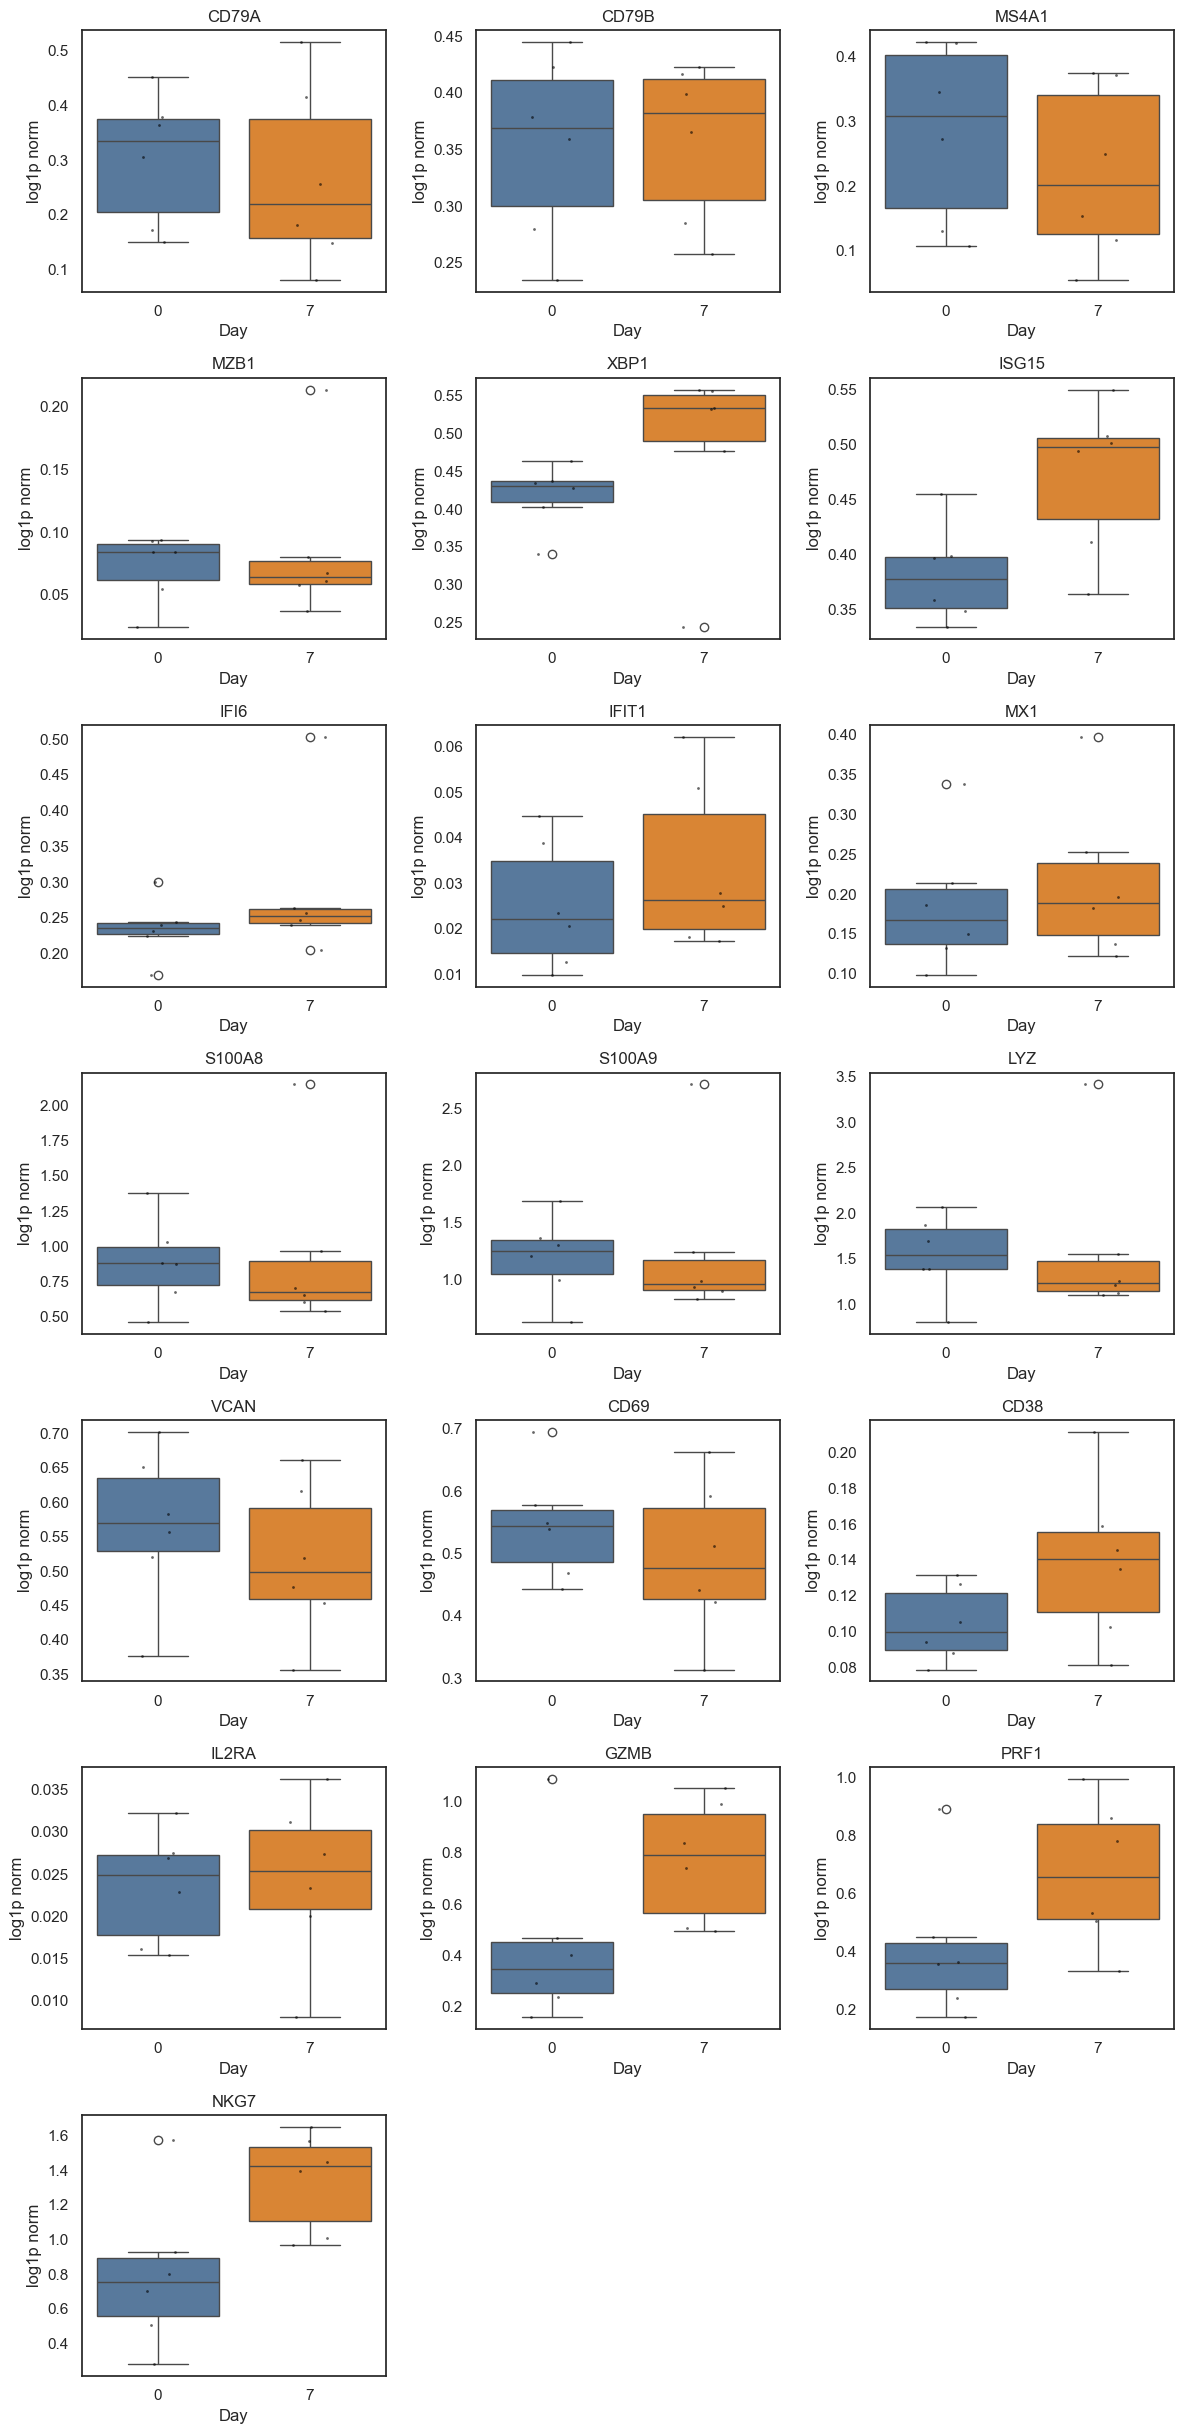

In [12]:
print("=" * 60)
print("WITHIN-ARM COMPARISONS: PANEL GENES (Day 0 vs Day 7)")
print("=" * 60)
res_genes = pd.DataFrame()
if panel_genes and len(visits) == 2:
    ad_sub = adata_analysis[adata_analysis.obs["participant_id"].isin(VALID_PAIRED_IDS)].copy()
    res_genes = st.within_arm_comparison(
        ad_sub,
        arm="All",
        features=panel_genes,
        design=design,
        visits=tuple(visits),
        aggregate="participant_visit",
        standardize=True,
        layer="log1p_norm",
        use_bootstrap=True,   # Recommended for small n (6 participants)
        n_boot=999,
        seed=SEED,
    )
    if res_genes is not None and not res_genes.empty:
        # Use package helper for FDR correction
        res_genes = ensure_fdr(res_genes, p_col="p_time", fdr_col="FDR_time")
        display_cols = [
            "feature", "beta_time", "se_time", "p_time",
            "p_time_boot", "se_time_boot", "ci_lo_boot", "ci_hi_boot",
            "FDR_time", "n_units",
        ]
        display_cols = [c for c in display_cols if c in res_genes.columns]
        display(res_genes[display_cols].round(4))
        sig = res_genes[(res_genes["FDR_time"].notna()) & (res_genes["FDR_time"] < FDR_ALPHA)]
        if not sig.empty:
            print("")
            print(f"Panel genes with significant changes (FDR < {FDR_ALPHA}):")
            for _, row in sig.iterrows():
                direction = "increased" if row["beta_time"] > 0 else "decreased"
                print(f"  {row['feature']}: {direction} (beta={row['beta_time']:.3f}, FDR={_fmt_fdr(row['FDR_time'])})")
        else:
            print("")
            print(f"No panel genes reached FDR < {FDR_ALPHA}.")
    else:
        print("No within-arm results for panel genes.")
else:
    print("No panel genes available or missing visits.")
print("")
print("Boxplots show participant-level log1p norm by day; points indicate individual participants.")
# Plot participant-level panel genes by day (log1p norm)
if panel_genes and len(visits) == 2:
    df_expr = adata_analysis.obs[["participant_id", "visit"]].copy()
    for g in panel_genes:
        df_expr[g] = st.extract_gene_vector(adata_analysis, g, layer="log1p_norm")
    df_plot = (
        df_expr
        .groupby(["participant_id", "visit"], observed=True)[panel_genes]
        .mean()
        .reset_index()
    )
    n_feats = len(panel_genes)
    n_cols = min(3, n_feats)
    n_rows = (n_feats + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3.5*n_rows))
    axes = np.array(axes).reshape(-1)
    for i, feat in enumerate(panel_genes):
        ax = axes[i]
        sns.boxplot(
            data=df_plot,
            x="visit",
            y=feat,
            hue="visit",
            ax=ax,
            order=visits,
            palette={"0": "#4C78A8", "7": "#F58518"},
            dodge=False,
            linewidth=1,
        )
        sns.stripplot(
            data=df_plot,
            x="visit",
            y=feat,
            ax=ax,
            order=visits,
            color="black",
            size=2,
            alpha=0.6,
            jitter=0.15,
        )
        ax.set_title(feat)
        ax.set_xlabel("Day")
        ax.set_ylabel("log1p norm")
        if ax.legend_:
            ax.legend_.remove()
    for j in range(i+1, len(axes)):
        axes[j].axis("off")
    plt.tight_layout()
    plt.show()

## 8. Pseudobulk Within-Arm (Panel Genes)

Here, we aggregate counts to pseudobulk profiles and quantify gene‑level shifts by cell type.

> **Exploratory only:** With permissive thresholds (`min_cells_per_group=5`, `min_paired=3`), many cell-type pools have very few paired observations (n≈5), producing discrete p-value distributions and unstable estimates. Treat these as hypothesis-generating, not confirmatory.

/Users/vasanthakup/Documents/Work/umcAmsterdam/sctrial/sctrial_venv/lib/python3.13/site-packages/scipy/stats/_wilcoxon.py:178: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se


Pseudobulk paired deltas with Wilcoxon signed-rank test (panel genes × cell type):


/Users/vasanthakup/Documents/Work/umcAmsterdam/sctrial/sctrial_venv/lib/python3.13/site-packages/scipy/stats/_wilcoxon.py:178: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se
/Users/vasanthakup/Documents/Work/umcAmsterdam/sctrial/sctrial_venv/lib/python3.13/site-packages/scipy/stats/_wilcoxon.py:178: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se
/Users/vasanthakup/Documents/Work/umcAmsterdam/sctrial/sctrial_venv/lib/python3.13/site-packages/scipy/stats/_wilcoxon.py:178: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se
/Users/vasanthakup/Documents/Work/umcAmsterdam/sctrial/sctrial_venv/lib/python3.13/site-packages/scipy/stats/_wilcoxon.py:178: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se


,celltype,feature,n_units,mean_delta,median_delta,p_time,FDR_time
74,C6_CD8 T,PRF1,6,0.548281,0.352451,0.03125,0.362288
75,C6_CD8 T,NKG7,6,0.296983,0.189454,0.03125,0.362288
69,C6_CD8 T,VCAN,6,-1.334576,-1.385715,0.03125,0.362288
27,C3_CD14+ monocytes,MX1,6,0.301871,0.225520,0.03125,0.362288
32,C3_CD14+ monocytes,CD69,6,-1.042964,-0.946489,0.03125,0.362288
113,C1_NK,NKG7,5,0.209747,0.122444,0.06250,0.362288
114,C7_cDC2,CD79A,6,-0.700714,-0.599609,0.06250,0.362288
49,C10_Naive CD8 T,LYZ,5,-1.617291,-1.729764,0.06250,0.362288
48,C10_Naive CD8 T,S100A9,5,-1.781619,-1.684003,0.06250,0.362288
47,C10_Naive CD8 T,S100A8,5,-1.522718,-1.711392,0.06250,0.362288


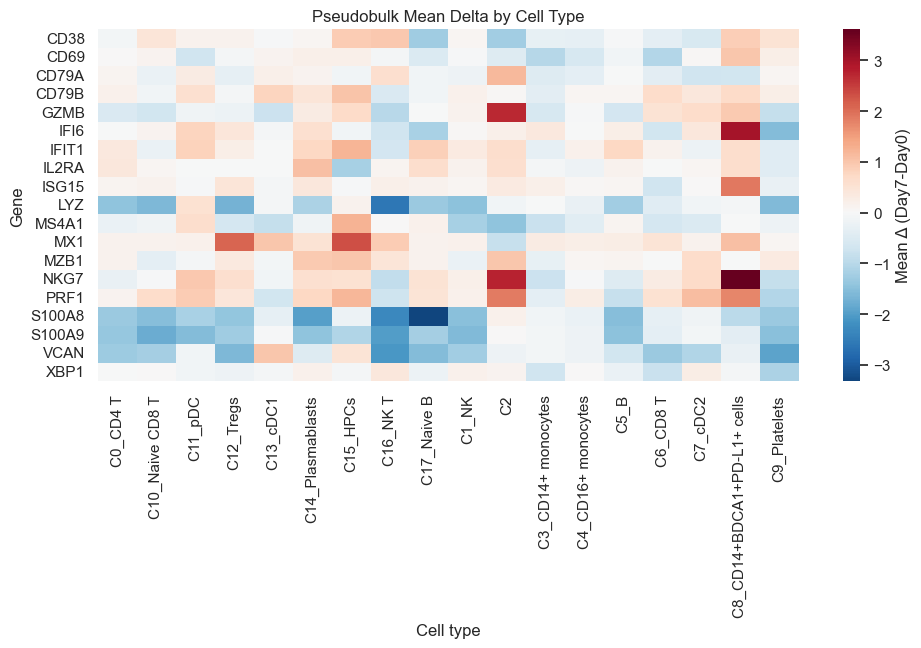

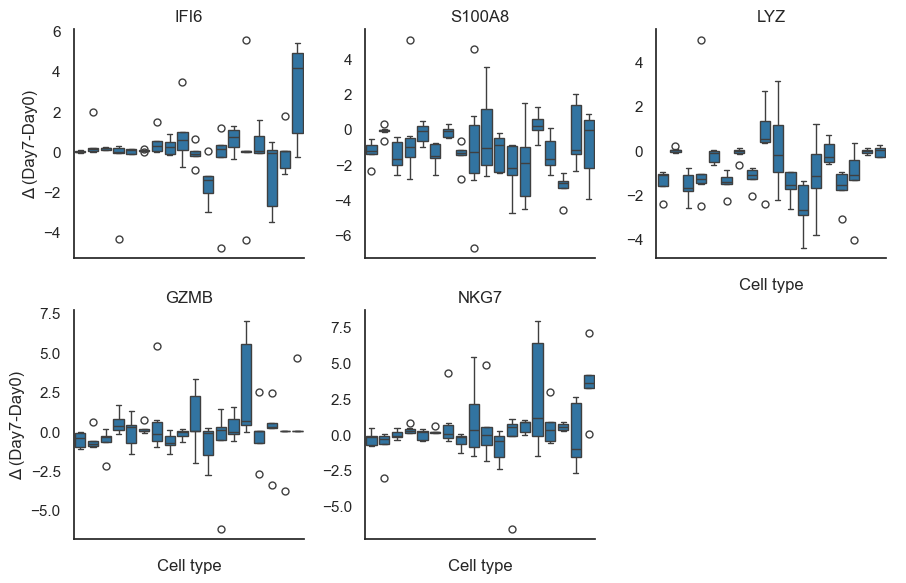

In [13]:
# Note: scipy.stats.wilcoxon warns 'Sample size too small for normal approximation'
# when n <= 20, but uses exact p-values internally — the results are correct.
import warnings as _w
_w.filterwarnings('ignore', message='Sample size too small', category=UserWarning)

from scipy.stats import wilcoxon
if panel_genes and n_paired >= MIN_PAIRED and len(visits) == 2:
    # Use package helper for pseudobulk within-arm analysis
    pb, pb_deltas = st.pseudobulk_within_arm(
        adata_analysis,
        genes=panel_genes,
        participant_col="participant_id",
        visit_col=design.visit_col,
        visits=visits,
        celltype_col=design.celltype_col,
        counts_layer="counts",
        min_paired=MIN_PAIRED,
    )
    if not pb.empty:
        print("Pseudobulk paired deltas with Wilcoxon signed-rank test (panel genes × cell type):")
        display(pb.sort_values(["p_time"]).head(30))
        sig = pb[(pb["FDR_time"].notna()) & (pb["FDR_time"] < FDR_ALPHA)]
        if not sig.empty:
            print("")
            print(f"Significant pseudobulk changes (FDR < {FDR_ALPHA}):")
            for _, row in sig.iterrows():
                direction = "↑" if row["mean_delta"] > 0 else "↓"
                print(f"  {row['celltype']} - {row['feature']}: {direction} (delta={row['mean_delta']:.3f}, FDR={_fmt_fdr(row['FDR_time'])})")
    else:
        print("No pseudobulk results generated.")
    # Pseudobulk heatmap (mean delta by cell type × gene)
    if not pb.empty:
        sns.set_style("white")
        pivot = pb.pivot(index="feature", columns="celltype", values="mean_delta")
        plt.figure(figsize=(10, max(4, 0.35*len(pivot))))
        ax = plt.gca()
        sns.heatmap(
            pivot,
            cmap="RdBu_r",
            center=0,
            cbar_kws={"label": "Mean Δ (Day7-Day0)"},
            linewidths=0,
            linecolor="none",
        )
        ax.set_axisbelow(False)
        plt.title("Pseudobulk Mean Delta by Cell Type")
        plt.xlabel("Cell type")
        plt.ylabel("Gene")
        plt.tight_layout()
        plt.show()
    # Distribution plots for top genes (by absolute mean delta)
    if not pb.empty and not pb_deltas.empty:
        top_genes = (
            pb.assign(abs_delta=pb["mean_delta"].abs())
            .sort_values("abs_delta", ascending=False)
            .head(6)["feature"].unique()
        )
        plot_df = pb_deltas[pb_deltas["feature"].isin(top_genes)].copy()
        if not plot_df.empty:
            g = sns.catplot(
                data=plot_df,
                x="celltype",
                y="delta",
                col="feature",
                kind="box",
                col_wrap=3,
                sharey=False,
                height=3,
            )
            g.set_titles("{col_name}")
            g.set_xticklabels(rotation=45, ha="right")
            g.set_axis_labels("Cell type", "Δ (Day7-Day0)")
            plt.tight_layout()
            plt.show()
else:
    print("Insufficient paired participants for pseudobulk.")


## 9. Trial Interaction Plot (Single Arm)

Here, we visualize paired trajectories to interpret direction and magnitude of change.

> **Note:** The plot below shows trajectories for the **first module score** (`features[0]`). Change the index to visualize other modules.

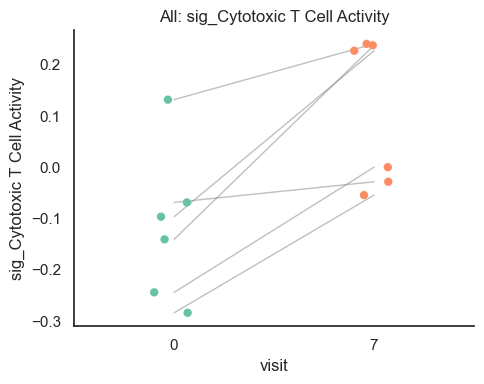

In [14]:
if features and len(visits) == 2:
    fig, ax = plt.subplots(1, 1, figsize=(5, 4))
    st.plot_within_arm_comparison(
        adata_analysis,
        arm="All",
        feature=features[0],
        design=design,
        visits=tuple(visits),
        plot_type="paired",
        ax=ax,
    )
    plt.tight_layout(); plt.show()


## 10. Trial UMAP Panel for a Module Score

Here, we overlay a module score on the UMAP to localize signal to specific cell populations.


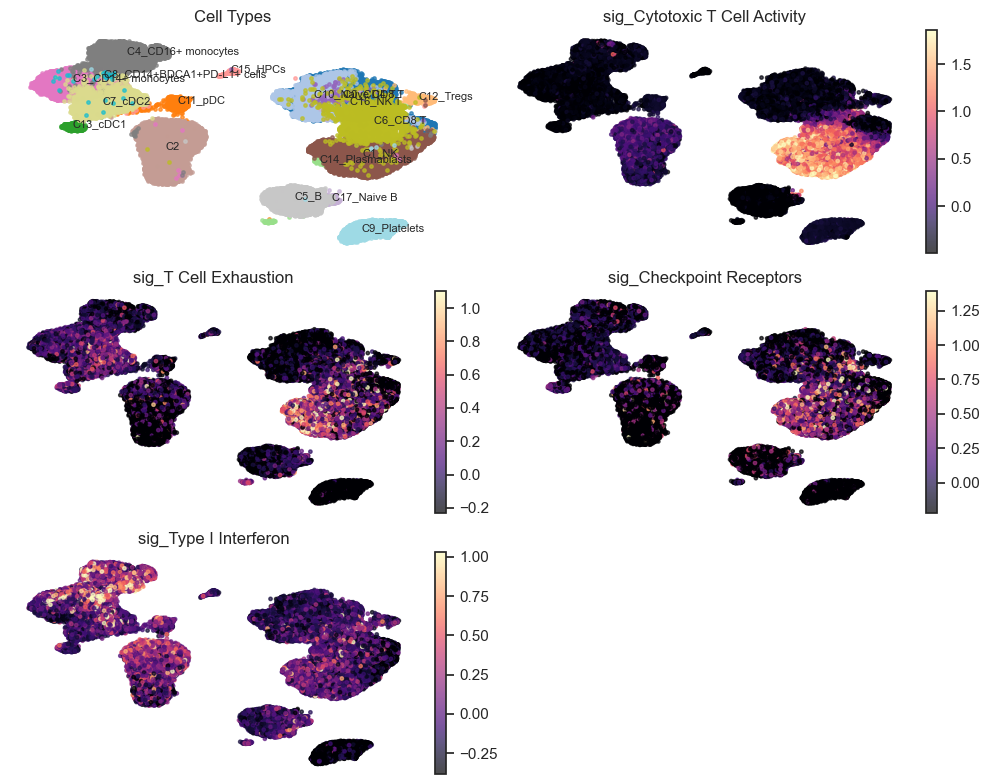

In [15]:
if features:
    modules = features[:4]
    if "X_umap" not in adata_analysis.obsm:
        # Ensure UMAP is computed on log1p_norm (same as Section 4)
        adata_analysis.X = adata_analysis.layers["log1p_norm"].copy()
        sc.pp.pca(adata_analysis)
        sc.pp.neighbors(adata_analysis)
        sc.tl.umap(adata_analysis)
    fig = st.plot_module_umap_panel(
        adata_analysis,
        module_cols=modules,
        celltype_col="cell_type",
        umap_key="X_umap",
        n_cols=2,
        figsize=(10, 8),
        point_size=6,
        alpha=0.7,
    )
    plt.show()
else:
    print("No module scores available for UMAP panel.")


## 11. Dotplot of Panel Genes

Here, we summarize gene expression patterns **across visits** (Day 0 vs Day 7) in a compact dotplot.


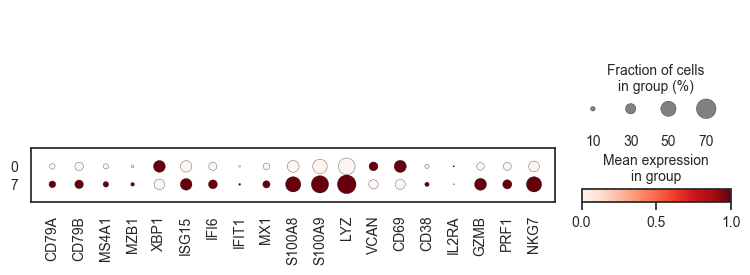

In [16]:
if panel_genes:
    sc.pl.dotplot(
        adata_analysis,
        panel_genes,
        groupby=design.visit_col,
        standard_scale="var",
        use_raw=False,
    )


## 12. Advanced Statistical Analyses

Statistical modules for within-arm longitudinal studies:
- **Effect sizes**: Cohen's d for paired within-arm changes
- **Power analysis**: Current power and sample size planning
- **Effective sample size**: Accounting for cell-level clustering


### 12.1 Effect Sizes for Within-Arm Changes

For within-arm paired studies, **paired** effect sizes quantify the magnitude of change from baseline.


EFFECT SIZE ANALYSIS (Within-Arm)

Effect sizes for Day 0 → Day 7 changes:
  d_paired: standardized within-subject change (delta_mean / sd_delta)
  g_paired: bias-corrected paired effect size (Hedge's J correction)



,feature,mean_delta,d_paired,g_paired,ci_lower,ci_upper,n_paired
0,sig_Cytotoxic T Cell Activity,0.221,1.733,1.459,0.926,4.394,6
1,sig_T Cell Exhaustion,0.038,0.583,0.491,-0.114,4.025,6
2,sig_Checkpoint Receptors,0.046,0.552,0.464,-0.197,2.794,6
3,sig_Type I Interferon,0.063,1.532,1.290,0.788,2.897,6
4,sig_Type II Interferon,0.010,0.326,0.274,-2.344,0.863,6
5,sig_Memory T Cell,-0.115,-0.663,-0.559,-1.319,-0.106,6
6,sig_T Cell Activation,-0.047,-0.761,-0.641,-1.660,-0.316,6
7,sig_Inflammatory Response,-0.006,-0.204,-0.172,-1.065,0.663,6
8,sig_Antigen Presentation,0.102,0.716,0.603,0.303,1.439,6
9,sig_Cell Proliferation,0.027,1.590,1.339,1.002,8.385,6


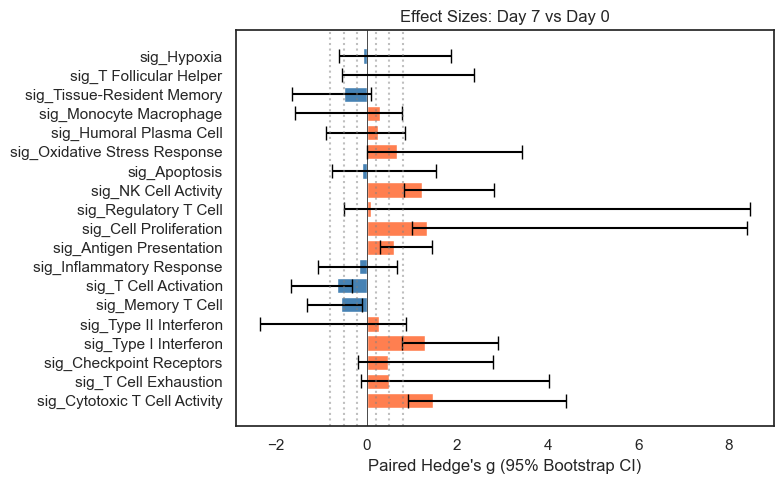

In [17]:
print("=" * 60)
print("EFFECT SIZE ANALYSIS (Within-Arm)")
print("=" * 60)
if features and len(visits) == 2:
    # Aggregate to participant-visit level
    df_agg = (
        adata_analysis.obs[adata_analysis.obs["participant_id"].isin(VALID_PAIRED_IDS)]
        .groupby(["participant_id", "visit"], observed=True)[features]
        .mean()
        .reset_index()
    )
    
    effect_results = []
    for feat in features:
        # Pivot to wide format
        wide = df_agg.pivot(index="participant_id", columns="visit", values=feat)
        
        if visits[0] not in wide.columns or visits[1] not in wide.columns:
            continue
        
        wide = wide.dropna()
        pre_vals = wide[visits[0]].values
        post_vals = wide[visits[1]].values
        
        if len(pre_vals) >= 3:
            # Paired effect size: standardized mean of within-subject differences
            delta = post_vals - pre_vals
            sd_delta = delta.std(ddof=1)
            d_paired = delta.mean() / sd_delta if sd_delta > 0 else np.nan
            
            # Hedge's correction for small-sample bias (paired df = n-1)
            n = len(delta)
            j = 1 - 3 / (4 * (n - 1) - 1) if n > 2 else 1.0
            g_paired = d_paired * j if not np.isnan(d_paired) else np.nan
            
            # Bootstrap CI for paired effect size
            rng = np.random.default_rng(SEED)
            boot_ds = []
            for _ in range(999):
                idx = rng.choice(n, size=n, replace=True)
                d_boot = delta[idx]
                sd_b = d_boot.std(ddof=1)
                boot_ds.append(d_boot.mean() / sd_b * j if sd_b > 0 else np.nan)
            boot_ds = np.array(boot_ds)
            boot_ds = boot_ds[np.isfinite(boot_ds)]
            ci_low = np.percentile(boot_ds, 2.5) if len(boot_ds) > 0 else np.nan
            ci_high = np.percentile(boot_ds, 97.5) if len(boot_ds) > 0 else np.nan
            
            effect_results.append({
                "feature": feat,
                "mean_delta": delta.mean(),
                "d_paired": d_paired,
                "g_paired": g_paired,
                "ci_lower": ci_low,
                "ci_upper": ci_high,
                "n_paired": len(pre_vals),
            })
    
    if effect_results:
        df_effect = pd.DataFrame(effect_results)
        
        print("\nEffect sizes for Day 0 → Day 7 changes:")
        print("  d_paired: standardized within-subject change (delta_mean / sd_delta)")
        print("  g_paired: bias-corrected paired effect size (Hedge's J correction)")
        print("")
        display(df_effect.round(3))
        
        # Visualize
        fig, ax = plt.subplots(figsize=(8, 5))
        y_pos = np.arange(len(df_effect))
        
        ax.barh(y_pos, df_effect["g_paired"], xerr=[
            df_effect["g_paired"] - df_effect["ci_lower"],
            df_effect["ci_upper"] - df_effect["g_paired"]
        ], capsize=5, color=["coral" if g > 0 else "steelblue" for g in df_effect["g_paired"]])
        ax.axvline(0, color="black", linewidth=0.5)
        ax.set_yticks(y_pos)
        ax.set_yticklabels(df_effect["feature"])
        ax.set_xlabel("Paired Hedge's g (95% Bootstrap CI)")
        ax.set_title("Effect Sizes: Day 7 vs Day 0")
        
        # Reference lines
        for thresh in [-0.8, -0.5, -0.2, 0.2, 0.5, 0.8]:
            ax.axvline(thresh, color="gray", linestyle=":", alpha=0.5)
        
        plt.tight_layout()
        plt.show()
else:
    print("Effect size analysis requires paired visits.")


### 12.2 Power Analysis

Power analysis for within-arm studies helps plan future studies and understand current study limitations.


POWER ANALYSIS (Within-Arm Paired Design)

Current paired sample size: 6 participants

Power with n=6 paired participants (paired t-test):
  Effect size d=0.5: 13.9% power
  Effect size d=0.8: 28.3% power
  Effect size d=1.0: 41.0% power
  Effect size d=1.5: 73.8% power
  Effect size d=2.0: 93.4% power

Sample size needed for 80% power (paired design):
  Effect size d=0.5: 63 participants
  Effect size d=0.8: 25 participants
  Effect size d=1.0: 16 participants
  Effect size d=1.5: 7 participants
  Effect size d=2.0: 4 participants


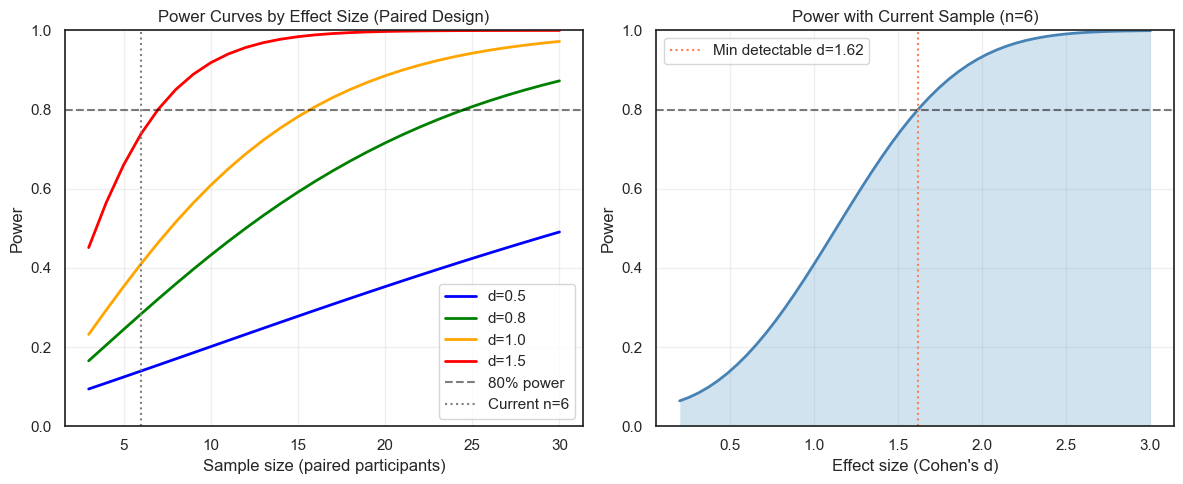


EFFECTIVE SAMPLE SIZE

Participants: 6
Total cells: 78,456
Average cells per participant: 13076

Design effect and effective sample size (cells within participant):
  n_clusters = number of participants (not total cells)
  ICC=0.01: Design effect=131.8, Effective n=595
  ICC=0.05: Design effect=654.8, Effective n=120
  ICC=0.1: Design effect=1308.5, Effective n=60
  ICC=0.2: Design effect=2616.0, Effective n=30

Note: Participant-level aggregation accounts for clustering automatically.


In [18]:
print("=" * 60)
print("POWER ANALYSIS (Within-Arm Paired Design)")
print("=" * 60)

# Use sctrial's paired power functions (single-arm pre/post design).
# These are the correct functions for a paired study — do NOT use
# power_did() which assumes a two-arm DiD design.

# Current sample size
n_paired = N_VALID_PAIRED
print(f"\nCurrent paired sample size: {n_paired} participants")

# Power for different effect sizes
print(f"\nPower with n={n_paired} paired participants (paired t-test):")
for effect_size in [0.5, 0.8, 1.0, 1.5, 2.0]:
    pwr = st.power_paired(n_participants=n_paired, effect_size=effect_size)
    print(f"  Effect size d={effect_size}: {pwr:.1%} power")

# Sample sizes needed for 80% power
print("\nSample size needed for 80% power (paired design):")
for effect_size in [0.5, 0.8, 1.0, 1.5, 2.0]:
    n_needed = st.sample_size_paired(effect_size=effect_size, power=0.80)
    print(f"  Effect size d={effect_size}: {n_needed} participants")

# Power curve visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Power curve across sample sizes
n_range = np.arange(3, 31)
for effect_size, color in [(0.5, "blue"), (0.8, "green"), (1.0, "orange"), (1.5, "red")]:
    powers = [st.power_paired(n_participants=n, effect_size=effect_size) for n in n_range]
    axes[0].plot(n_range, powers, label=f"d={effect_size}", color=color, linewidth=2)
axes[0].axhline(0.8, color="black", linestyle="--", alpha=0.5, label="80% power")
axes[0].axvline(n_paired, color="gray", linestyle=":", label=f"Current n={n_paired}")
axes[0].set_xlabel("Sample size (paired participants)")
axes[0].set_ylabel("Power")
axes[0].set_title("Power Curves by Effect Size (Paired Design)")
axes[0].legend(loc="lower right")
axes[0].set_ylim(0, 1)
axes[0].grid(True, alpha=0.3)

# Power with current sample across effect sizes
effect_range = np.linspace(0.2, 3.0, 50)
power_current = [st.power_paired(n_participants=n_paired, effect_size=e) for e in effect_range]
axes[1].plot(effect_range, power_current, linewidth=2, color="steelblue")
axes[1].axhline(0.8, color="black", linestyle="--", alpha=0.5)
axes[1].fill_between(effect_range, 0, power_current, alpha=0.2)
axes[1].set_xlabel("Effect size (Cohen's d)")
axes[1].set_ylabel("Power")
axes[1].set_title(f"Power with Current Sample (n={n_paired})")
axes[1].set_ylim(0, 1)
axes[1].grid(True, alpha=0.3)

# Mark minimum detectable effect
mde = st.sensitivity_paired(n_participants=n_paired, power=0.80)
axes[1].axvline(mde, color="coral", linestyle=":",
                label=f"Min detectable d={mde:.2f}")
axes[1].legend()
plt.tight_layout()
plt.show()

# Effective sample size
print("\n" + "=" * 60)
print("EFFECTIVE SAMPLE SIZE")
print("=" * 60)
cells_per_participant = adata_analysis.obs.groupby("participant_id").size()
avg_cells = cells_per_participant.mean()
total_cells = adata_analysis.n_obs
n_participants = adata_analysis.obs["participant_id"].nunique()
print(f"\nParticipants: {n_participants}")
print(f"Total cells: {total_cells:,}")
print(f"Average cells per participant: {avg_cells:.0f}")
print("\nDesign effect and effective sample size (cells within participant):")
print("  n_clusters = number of participants (not total cells)")
for icc in [0.01, 0.05, 0.10, 0.20]:
    de = st.design_effect(avg_cells, icc)
    eff_n = st.effective_sample_size(n_participants, avg_cells, icc)
    print(f"  ICC={icc}: Design effect={de:.1f}, Effective n={eff_n:.0f}")
print("\nNote: Participant-level aggregation accounts for clustering automatically.")

### Pseudobulk Export

Here we export participant-level pseudobulk expression for downstream analyses.


In [19]:
pb = st.pseudobulk_export(
    adata_analysis,
    genes=panel_genes[:5] if panel_genes else adata_analysis.var_names[:5],
    design=design,
    visits=tuple(visits),
    celltype_col=design.celltype_col,
)
print(pb)
display(pb.obs.head())


AnnData object with n_obs × n_vars = 202 × 5
    obs: 'participant_id', 'visit', 'cell_type'


/opt/homebrew/Cellar/python@3.13/3.13.13_1/Frameworks/Python.framework/Versions/3.13/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


,participant_id,visit,cell_type
0,2047,0,C0_CD4 T
1,2047,0,C3_CD14+ monocytes
2,2047,0,C10_Naive CD8 T
3,2047,0,C6_CD8 T
4,2047,0,C4_CD16+ monocytes
